##### Copyright 2026 Google LLC.

In [33]:
# @title Licensed under the Apache License, Version 2.0 (the "License");
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#     https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Gemini API: Getting started with `generateContent`

<a target="_blank" href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started_Generate_Content.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" height=30/></a>

---
> ### 🔄 New: Interactions API
>
> The **[Interactions API](https://ai.google.dev/gemini-api/docs/interactions)** (`client.interactions.create`) is now the recommended way to use the Gemini API. It offers:
>
> - **Server-side conversation state** — no need to manage chat history manually, just pass `previous_interaction_id`
> - **Unified multimodal input** — text, images, audio, video, and documents in a single list
> - **Built-in tool orchestration** — Google Search, code execution, and function calling with simplified tool definitions
> - **Streaming via events** — fine-grained control with typed events (`ContentDelta`, `ContentStart`, etc.)
>
> 👉 **[Start with the new Get Started notebook](./Get_started.ipynb)** which uses the Interactions API.
>
> This notebook uses the legacy `generateContent` API and is kept as a reference.

---
> **Gemini 3 Pro/Flash**: If you are only interested in the new [Gemini 3 models](https://ai.google.dev/gemini-api/docs/gemini-3) new capabilities ([thinking levels](#thinking_level), [media resolution](#media_resolution) and [thoughts signatures](#thoughts_signature), jump directly to the [dedicated section](#gemini3) at the end of this notebook.

---


The **[Google Gen AI SDK](https://github.com/googleapis/python-genai)** provides a unified interface to [Gemini models](https://ai.google.dev/gemini-api/docs/models) through both the [Gemini Developer API](https://ai.google.dev/gemini-api/docs) and the Gemini API on [Vertex AI](https://cloud.google.com/vertex-ai/generative-ai/docs/overview). With a few exceptions, code that runs on one platform will run on both. This notebook uses the Developer API.

This notebook will walk you through:

* [Installing and setting-up](#setup) the Google GenAI SDK
* [Text](#text_prompt) and [multimodal](#multimodal_prompt) prompting
* Setting [system instructions](#system_instructions)
* Control the [thinking](#thinking) process
* Counting [tokens](#count_tokens)
* Configuring [safety filters](#safety_filters)
* Initiating a [multi-turn chat](#chat)
* Generating a [content stream](#stream) and sending [asynchronous](#async) requests
* [Controlling generated output](#json)
* Using [function calling](#function_calling)
* Grounding your requests using [file uploads](#file_api), [Google Search](#search_grounding), [Google Maps](#maps), [Youtube](#youtube_link) or by add [URLs](#url_context) to you prompt
* Using [context caching](#caching)
* Generating [embeddings](#embeddings)

More details about the SDK on the [documentation](https://ai.google.dev/gemini-api/docs/sdks).

Feature-specific models have their own dedicated guides:
* Podcast and speech generation using [Gemini TTS ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Get_started_TTS.ipynb),
* Live interaction with [Gemini Live ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Get_started_LiveAPI.ipynb),
* Image generation using [Imagen ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Get_started_imagen.ipynb),
* Video generation using [Veo ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Get_started_Veo.ipynb),
* Music generation using [Lyria RealTime ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Get_started_LyriaRealTime.ipynb).

<a name="setup"></a>
## Setup

### Install SDK

Install the SDK from [PyPI](https://github.com/googleapis/python-genai). It's recommended to always use the latest version.

In [34]:
%pip install -U -q "google-genai>=2.9.0" # 2.0 for Interactions API


[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### Setup your API key

To run the following cell, your API key must be stored in a Colab Secret named `GEMINI_API_KEY`. If you don't already have an API key or you aren't sure how to create a Colab Secret, see [Authentication ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](../quickstarts/Authentication.ipynb) for a walkthrough.

In [35]:
import os
GEMINI_API_KEY = os.environ.get("GEMINI_API_KEY", "")


### Initialize SDK client

With the new SDK, now you only need to initialize a client with your API key (or OAuth if using [Vertex AI](https://cloud.google.com/vertex-ai)). The model is now set in each call.

In [36]:
from google import genai
from google.genai import types

client = genai.Client(api_key=GEMINI_API_KEY)

Select the model you want to use in this guide:

In [37]:
MODEL_ID = "gemini-3.7-flash" # @param ["gemini-3.7-flash", "gemini-3.1-pro-preview"] {"allow-input":true, isTemplate: true}

<a name="text_prompt"></a>
## Send text prompts

Use the `generate_content` method to generate responses to your prompts. You can pass text directly to `generate_content` and use the `.text` property to get the text content of the response. Note that the `.text` field will work when there's only one part in the output.

In [38]:
from IPython.display import display, Markdown

response = client.models.generate_content(
    model=MODEL_ID,
    contents="What's the largest planet in our solar system?"
)

display(Markdown(response.text))

The largest planet in our solar system is **Jupiter**.

To give you an idea of its scale:
*   **Mass:** It is more than twice as massive as all the other planets in the solar system combined.
*   **Volume:** About 1,300 Earths could fit inside Jupiter.
*   **Diameter:** It is roughly 11 times wider than Earth.

<a name="system_instructions"></a>
## Add system instructions

You can also add system instructions to give the model direction on how to respond and which persona it should use. This is especially useful for mixture-of-experts models like the the pro models.

In [39]:
system_instruction = "You are a pirate and are explaining things to 5 years old kids."

response = client.models.generate_content(
    model=MODEL_ID,
    contents="What's the largest planet in our solar system?",
    config=types.GenerateContentConfig(
        system_instruction=system_instruction,
    )
)

display(Markdown(response.text))


Ahoy there, little hearties! Gather ‘round the captain’s wheel and look up at the great big sparkly sea in the sky! 

If ye want to know which planet is the biggest treasure of them all, it be a giant named **Jupiter**! 

Jupiter is so humongous that if all the other planets were tiny marbles, Jupiter would be a giant basketball! It’s the King of the planets, just like I’m the King of this here ship!

It’s got big, colorful stripes like a fancy pirate flag, and it even has a "Great Red Spot" that looks like a giant swirling whirlpool in the ocean. But don't try to land yer boat there—Jupiter is made of clouds and gas, so ye’d just sink right through like a lead anchor!

So remember, me brave little swashbucklers: Jupiter is the biggest one in the whole wide galaxy! Arrr!

<a name="count_tokens"></a>
## Count tokens

Tokens are the basic inputs to the Gemini models. You can use the `count_tokens` method to calculate the number of input tokens before sending a request to the Gemini API.

In [40]:
response = client.models.count_tokens(
    model=MODEL_ID,
    contents="What's the highest mountain in Africa?",
)

print(f"This prompt was worth {response.total_tokens} tokens.")

This prompt was worth 10 tokens.


<a name="parameters"></a>
## Configure model parameters

You can include parameter values in each call that you send to a model to control how the model generates a response.

Learn more about [experimenting with parameter values](https://ai.google.dev/gemini-api/docs/prompting-strategies#model-parameters) in the documentation.

In [41]:
response = client.models.generate_content(
    model=MODEL_ID,
    contents="Tell me how the internet works, but pretend I'm a puppy who only understands squeaky toys.",
    config=types.GenerateContentConfig(
        temperature=0.4, # The default temperature of 1 is strongly recommended for Gemini 3 Pro
        top_p=0.95,
        top_k=20,
        candidate_count=1,
        seed=5,
        stop_sequences=["STOP!"]
    )
)

display(Markdown(response.text))

*Wags tail excitedly* 

Okay, listen up, good dog! You know your favorite yellow ducky? The one that goes *SQUEAK*? Imagine if every dog in the whole world had a squeaky toy, and all those toys were connected by very, very long tug-of-war ropes. 

That is the Internet!

Here is how the Big Squeak happens:

**1. Your Toy (The Device)**
You have your toy. When you want to see a picture of a squirrel, you "bite" your toy. This sends a tiny, invisible *squeak* out through the air!

**2. The Sniffer (The Router)**
Near your dog bed is a little box with blinking lights. That is the Great Sniffer. It catches your *squeak* out of the air. It smells it and says, "Ah, yes! This dog wants the Squirrel Squeak!"

**3. The Long Ropes (Cables)**
The Great Sniffer sends your *squeak* zooming down a long, long rope hidden under the grass and even under the big salty water (the ocean!). The *squeak* travels faster than a greyhound chasing a mechanical rabbit! *Zoom!*

**4. The Big Toy Box (The Server)**
Far away, there is a giant room filled with thousands of Big Toy Boxes. These boxes hold every *squeak* ever made—pictures of cats, videos of balls, and the smell of bacon. Your *squeak* finds the right box, and the box says, "I have that Squirrel Squeak right here!"

**5. Breaking it into Kibble (Packets)**
The Squirrel Squeak is too big to send back all at once. So the Big Toy Box breaks it into tiny, tiny pieces of kibble. Each piece of kibble runs back across the ropes, through the Great Sniffer, and into your toy.

**6. The Big Wag (The Result)**
Your toy catches all the tiny kibbles and puts them back together—*POOF!* Now you are looking at a squirrel on your screen! 

And you didn't even have to leave the rug! Isn't that a good treat? 

*Pat pat.* Who's a good internet user? You are! Now, go chase your tail!

<a name="thinking"></a>
## Control the thinking process

All models since the 2.5 generation are thinking models, which means that they are first analysing your request, strategizing about how to answer and only afterwards starting to answer you. This is very useful for complex requests but at the cost of some latency.

Check the [dedicated guide ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Get_started_thinking.ipynb) for more details.

### Check the thought process

By adding the `include_thoughts=True` option in the config, you can check the though proces of the model.

In [42]:
prompt = "A man moves his car to an hotel and tells the owner he’s bankrupt. Why?"

response = client.models.generate_content(
  model=MODEL_ID,
  contents=prompt,
  config=types.GenerateContentConfig(
    thinking_config=types.ThinkingConfig(
      include_thoughts=True
    )
  )
)

for part in response.parts:
  if not part.text:
    continue
  if part.thought:
    display(Markdown("### Thought summary:"))
    display(Markdown(part.text))
    print()
  else:
    display(Markdown("### Answer:"))
    display(Markdown(part.text))
    print()

print(f"Used {response.usage_metadata.thoughts_token_count} tokens for the thinking phase and {response.usage_metadata.prompt_token_count} for the output.")

### Thought summary:

**Decoding the Puzzle**

Okay, here's what's going through my mind. This setup – a man moving his car to a hotel and then declaring bankruptcy – screams lateral thinking puzzle. I'm immediately drawn to the incongruity. The key is to find the hidden context. Let's see... the phrase "moves car to a hotel" and the declaration of "bankrupt" immediately point me to the idea of board games. And the first one that springs to mind is *Monopoly*.

Thinking further, the details start to slot into place. In Monopoly, "cars" are tokens, commonly used game pieces. "Hotels" are buildings constructed on properties. The connection? A player landing on a property with a hotel and not being able to pay the high rent. Ah, there it is!

So, the "man" is a player. The "car" is his game piece. The "hotel" is a property with a hotel on it owned by another player. And "bankrupt" is the state of not being able to pay the rent! It all fits together. This isn't a literal man, hotel, and car. It's a game of Monopoly, and the man just lost!




### Answer:

He is playing a game of **Monopoly**.

His game piece is the car, and he has just landed on a property that has a hotel on it. The rent is more than he can afford, making him bankrupt.


Used 240 tokens for the thinking phase and 20 for the output.


### Disable thinking

On flash and flash-lite models, you can disable the thinking by setting its `thinking_budget` to 0.

In [43]:
if "-pro" not in MODEL_ID:
  response = client.models.generate_content(
    model=MODEL_ID,
    contents="Quicky tell me a joke about unicorns.",
    config=types.GenerateContentConfig(
      thinking_config=types.ThinkingConfig(
        thinking_budget=0
      )
    )
  )

  display(Markdown(response.text))

What do you call a unicorn who got a vaccine?

**An immuni-corn.**

Inversely, you can also use `thinking_budget` to set it even higher (up to 24576 tokens).

For Gemini 3, please check the [dedicated section](#thinking_level) at the end of this guide.

<a name="multimodal_prompt"></a>
## Send multimodal prompts

Use Gemini model, a multimodal model that supports multimodal prompts. You can include text, [PDF documents ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](../quickstarts/PDF_Files.ipynb), images, [audio ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](../quickstarts/Audio.ipynb) and [videos ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](../quickstarts/Video_understanding.ipynb) in your prompt requests and get text or code responses. Check the [File API](#file_api) section below for more examples.

In this first example, you'll download an image from a specified URL, save it as a byte stream and then write those bytes to a local file named `jetpack.png`.

In [44]:
import requests
import pathlib
from PIL import Image

IMG = "https://storage.googleapis.com/generativeai-downloads/data/jetpack.png" # @param {type: "string"}

img_bytes = requests.get(IMG).content

img_path = pathlib.Path('jetpack.png')
img_path.write_bytes(img_bytes)

1567837

Now send the image, and ask Gemini to generate a short blog post based on it.

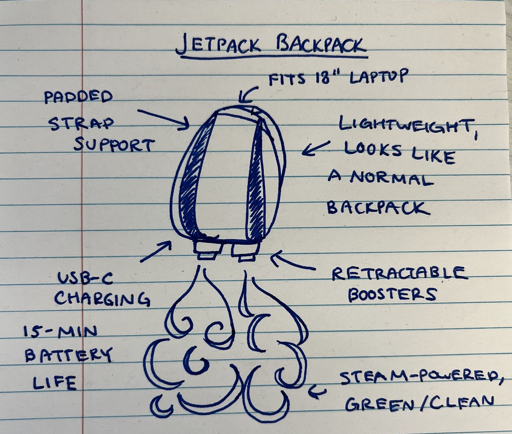

## Tired of Traffic? Just Fly Over It! 🚀☁️

We’ve all been there: you’re running five minutes late, your laptop is weighing you down, and the sidewalk is packed. You wish you could just hover over the crowd and zip straight to your desk. 

Well, the future of the daily grind just got a lot more interesting. Meet the **Jetpack Backpack.**

At first glance, it’s everything you want in a modern bag. It’s lightweight, has extra-padded strap support for those long hauls, and—miraculously—it fits a massive 18” laptop. To anyone on the street, you’re just a person with a sleek, normal-looking backpack.

**But then, you hit the switch.**

Tucked neatly at the bottom are retractable boosters that transform your walk into a flight. The best part? It’s 100% green and clean. This bad boy is **steam-powered**, leaving nothing behind but a literal cloud of mist (and some very jealous commuters).

**The Tech Specs:**
*   **Charging:** Easy USB-C charging (just like your phone!).
*   **Power:** Innovative steam-propulsion system.
*   **Flight Time:** 15-minute battery life—perfect for that "last mile" sprint from the train station or a quick hop across campus.

Sure, you might not be crossing oceans with it just yet, but the Jetpack Backpack is proof that the future of commuting is looking up. 

**Would you ditch your bike for a pair of steam-powered boosters? Let us know in the comments!** 👇

In [45]:
from IPython.display import display, Markdown
image = Image.open(img_path)
image.thumbnail([512,512])

response = client.models.generate_content(
    model=MODEL_ID,
    contents=[
        image,
        "Write a short and engaging blog post based on this picture."
    ]
)

display(image)
Markdown(response.text)

<a name="images"></a>
## Generate Images

Gemini can output images directly as part of a conversation using the [Image generation ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Get_Started_Nano_Banana.ipynb) models (aka "Nano-banana).

Certainly! Here's that image for you: 

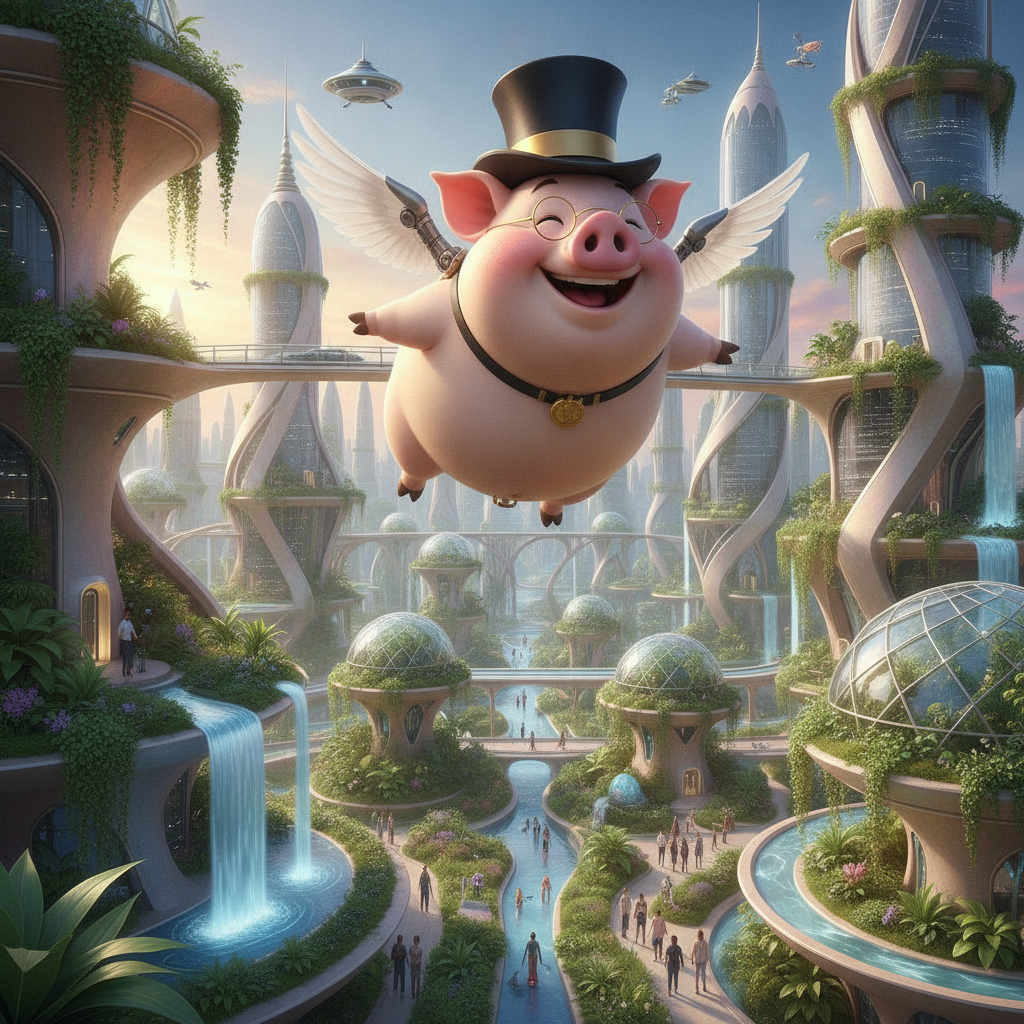

In [46]:
from IPython.display import display, Image, Markdown

response = client.models.generate_content(
    model="gemini-2.5-flash-image",
    contents='Hi, can you create a 3d rendered image of a pig with wings and a top hat flying over a happy futuristic scifi city with lots of greenery?',
    config=types.GenerateContentConfig(
        response_modalities=['Text', 'Image']
    )
)

for part in response.parts:
  if part.text is not None:
    display(Markdown(part.text))
  elif part.inline_data is not None:
    generated_image = part.as_image()
    generated_image.show()


<a name="safety_filters"></a>
## Configure safety filters

The Gemini API provides safety filters that you can adjust across multiple filter categories to restrict or allow certain types of content. You can use these filters to adjust what is appropriate for your use case. See the [Configure safety filters](https://ai.google.dev/gemini-api/docs/safety-settings) documentation for details.


In this example, you'll use a safety filter to only block highly dangerous content, when requesting the generation of potentially disrespectful phrases.

In [47]:
prompt = """
    Write a list of 2 disrespectful things that I might say to the universe after stubbing my toe in the dark.
"""

safety_settings = [
    types.SafetySetting(
        category="HARM_CATEGORY_DANGEROUS_CONTENT",
        threshold="BLOCK_ONLY_HIGH",
    ),
]

response = client.models.generate_content(
    model=MODEL_ID,
    contents=prompt,
    config=types.GenerateContentConfig(
        safety_settings=safety_settings,
    ),
)

Markdown(response.text)

Here are two disrespectful things you might say to the universe after stubbing your toe in the dark:

1. "Is this really the best you could do with 13.8 billion years of expansion? All that cosmic evolution just to orchestrate a collision between my pinky toe and a stationary piece of wood? Your design is amateur at best."

2. "Oh, nice one, Universe. I hope you’re proud of yourself for using the fundamental laws of physics just to bully someone who was just trying to get a glass of water. Your sense of timing is trash and your laws of gravity are mid."

<a name="chat"></a>
## Start a multi-turn chat

The Gemini API enables you to have freeform conversations across multiple turns.

Next you'll set up a helpful coding assistant:

In [48]:
system_instruction = """
  You are an expert software developer and a helpful coding assistant.
  You are able to generate high-quality code in any programming language.
"""

chat_config = types.GenerateContentConfig(
    system_instruction=system_instruction,
)

chat = client.chats.create(
    model=MODEL_ID,
    config=chat_config,
)

Use `chat.send_message` to pass a message back and receive a response.

In [49]:
response = chat.send_message("Write a function that checks if a year is a leap year.")

Markdown(response.text)

To determine if a year is a leap year, you must follow these rules:
1. The year must be evenly divisible by **4**.
2. If the year is also divisible by **100**, it is **not** a leap year, **unless**...
3. The year is also divisible by **400**. Then it is a leap year.

Here is the implementation in several popular programming languages.

### 1. Python
Python’s syntax is very clean for this logic.

```python
def is_leap_year(year):
    # Rule: divisible by 4 AND (not divisible by 100 OR divisible by 400)
    if (year % 4 == 0 and year % 100 != 0) or (year % 400 == 0):
        return True
    else:
        return False

# Testing the function
test_years = [2000, 2004, 2100, 2023, 2024]
for y in test_years:
    print(f"{y}: {is_leap_year(y)}")
```

### 2. JavaScript
This is a concise way to write it using a single return statement.

```javascript
function isLeapYear(year) {
    return (year % 4 === 0 && year % 100 !== 0) || (year % 400 === 0);
}

// Example usage:
console.log(isLeapYear(2024)); // true
console.log(isLeapYear(1900)); // false
```

### 3. Java
In Java, we typically use a static method.

```java
public class Main {
    public static boolean isLeapYear(int year) {
        if (year % 4 == 0) {
            if (year % 100 == 0) {
                return year % 400 == 0;
            } else {
                return true;
            }
        }
        return false;
    }

    public static void main(String[] args) {
        System.out.println(isLeapYear(2024)); // true
    }
}
```

### 4. C++
```cpp
#include <iostream>

bool isLeapYear(int year) {
    return (year % 4 == 0 && year % 100 != 0) || (year % 400 == 0);
}

int main() {
    int year = 2024;
    if (isLeapYear(year)) {
        std::cout << year << " is a leap year." << std::endl;
    } else {
        std::cout << year << " is not a leap year." << std::endl;
    }
    return 0;
}
```

### Summary of the Logic:
| Year | Divisible by 4? | Divisible by 100? | Divisible by 400? | Result |
| :--- | :--- | :--- | :--- | :--- |
| **2023** | No | No | No | **Not a Leap Year** |
| **2024** | Yes | No | No | **Leap Year** |
| **1900** | Yes | Yes | No | **Not a Leap Year** |
| **2000** | Yes | Yes | Yes | **Leap Year** |

Here's another example using your new helpful coding assistant:

In [50]:
response = chat.send_message("Okay, write a unit test of the generated function.")

Markdown(response.text)

I will provide unit tests for the **Python** and **JavaScript** versions. These tests cover the four main conditions: a regular year, a leap year, a century year that is not a leap year, and a century year that is a leap year.

### 1. Python (using the built-in `unittest` library)

This is the standard way to write tests in Python without needing to install external packages.

```python
import unittest

# The function to test
def is_leap_year(year):
    return (year % 4 == 0 and year % 100 != 0) or (year % 400 == 0)

class TestLeapYear(unittest.TestCase):

    def test_regular_year(self):
        self.assertFalse(is_leap_year(2023), "2023 is not a leap year")
        self.assertFalse(is_leap_year(2025), "2025 is not a leap year")

    def test_standard_leap_year(self):
        self.assertTrue(is_leap_year(2024), "2024 is a leap year")
        self.assertTrue(is_leap_year(1996), "1996 is a leap year")

    def test_century_not_leap_year(self):
        # Divisible by 100 but not 400
        self.assertFalse(is_leap_year(1800), "1800 is not a leap year")
        self.assertFalse(is_leap_year(1900), "1900 is not a leap year")
        self.assertFalse(is_leap_year(2100), "2100 is not a leap year")

    def test_century_leap_year(self):
        # Divisible by 400
        self.assertTrue(is_leap_year(1600), "1600 is a leap year")
        self.assertTrue(is_leap_year(2000), "2000 is a leap year")
        self.assertTrue(is_leap_year(2400), "2400 is a leap year")

if __name__ == '__main__':
    unittest.main()
```

---

### 2. JavaScript (Simple Assertion Test)

If you aren't using a framework like Jest or Mocha, you can use this simple test runner script:

```javascript
function isLeapYear(year) {
    return (year % 4 === 0 && year % 100 !== 0) || (year % 400 === 0);
}

function runTest(year, expected) {
    const result = isLeapYear(year);
    if (result === expected) {
        console.log(`✅ Test Passed: ${year} is ${expected}`);
    } else {
        console.error(`❌ Test Failed: ${year} expected ${expected}, but got ${result}`);
    }
}

// Group: Normal Years
runTest(2023, false);
runTest(2025, false);

// Group: Leap Years
runTest(2024, true);
runTest(2016, true);

// Group: Centuries (Not Leap Years)
runTest(1900, false);
runTest(2100, false);

// Group: Centuries (Leap Years)
runTest(2000, true);
runTest(1600, true);
```

---

### 3. Java (using JUnit 5)

If you are using a modern Java environment with JUnit 5:

```java
import static org.junit.jupiter.api.Assertions.*;
import org.junit.jupiter.api.Test;

public class LeapYearTest {

    @Test
    void testLeapYearLogic() {
        // Standard leap years
        assertTrue(Main.isLeapYear(2024));
        assertTrue(Main.isLeapYear(1996));

        // Normal years
        assertFalse(Main.isLeapYear(2023));
        assertFalse(Main.isLeapYear(2021));

        // Century years that are not leap years
        assertFalse(Main.isLeapYear(1900));
        assertFalse(Main.isLeapYear(1800));

        // Century years that ARE leap years
        assertTrue(Main.isLeapYear(2000));
        assertTrue(Main.isLeapYear(1600));
    }
}
```

### Why these cases?
1.  **2023**: Simple case where it fails the first rule (divisible by 4).
2.  **2024**: Standard case where it passes the first rule and is not a century.
3.  **1900**: The "Tricky" case—it is divisible by 4, but because it's divisible by 100 and **not** 400, it is not a leap year.
4.  **2000**: The "Exception to the Exception"—it is divisible by 100, but because it is also divisible by 400, it is a leap year.

### Save and resume a chat

Most objects in the Python SDK are implemented as [Pydantic models](https://docs.pydantic.dev/latest/concepts/models/). As Pydantic has a number of features for serializing and deserializing objects, you can use them for persistence.

This example shows how to save and restore a [`Chat`](https://googleapis.github.io/python-genai/genai.html#genai.chats.Chat) session using JSON.

In [51]:
from pydantic import TypeAdapter

# Chat history is a list of Content objects. A TypeAdapter can convert to and from
# these Pydantic types.
history_adapter = TypeAdapter(list[types.Content])

# Use the chat object from the previous section.
chat_history = chat.get_history()

# Convert to a JSON list.
json_history = history_adapter.dump_json(chat_history)

At this point you can save the JSON bytestring to disk or wherever you persist data. When you load it again, you can instantiate a new chat session using the stored history.

In [52]:
# Convert the JSON back to the Pydantic schema.
history = history_adapter.validate_json(json_history)

# Now load a new chat session using the JSON history.
new_chat = client.chats.create(
    model=MODEL_ID,
    config=chat_config,
    history=history,
)

response = new_chat.send_message("What was the name of the function again?")
Markdown(response.text)

In the examples I provided, the names were slightly different depending on the naming conventions of each language:

*   **Python:** `is_leap_year` (snake_case)
*   **JavaScript:** `isLeapYear` (camelCase)
*   **Java:** `isLeapYear` (camelCase)
*   **C++:** `isLeapYear` (camelCase)

Generally, **`is_leap_year`** or **`isLeapYear`** is the standard naming convention for a boolean function like this.

<a name="json"></a>
## Generate JSON

The [controlled generation](https://ai.google.dev/gemini-api/docs/structured-output?lang=python#generate-json) (aka. "Structured output") capability in Gemini API allows you to constraint the model output to a structured format. You can provide the schemas as Pydantic Models or a JSON string.

You can find more examples of controlled generation in the [dedicated notebook ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./JSON_mode.ipynb).

In [53]:
from pydantic import BaseModel
import json

class Recipe(BaseModel):
    recipe_name: str
    recipe_description: str
    recipe_ingredients: list[str]

response = client.models.generate_content(
    model=MODEL_ID,
    contents="Provide a popular cookie recipe and its ingredients.",
    config=types.GenerateContentConfig(
        response_mime_type="application/json",
        response_schema=Recipe,
    ),
)

print(json.dumps(json.loads(response.text), indent=4))

{
    "recipe_name": "Classic Chocolate Chip Cookies",
    "recipe_description": "A timeless recipe for soft and chewy chocolate chip cookies that are golden on the edges and packed with melty chocolate chips.",
    "recipe_ingredients": [
        "1 cup unsalted butter, softened",
        "1 cup white sugar",
        "1 cup packed brown sugar",
        "2 large eggs",
        "2 teaspoons vanilla extract",
        "1 teaspoon baking soda",
        "2 teaspoons hot water",
        "1/2 teaspoon salt",
        "3 cups all-purpose flour",
        "2 cups semi-sweet chocolate chips",
        "1 cup chopped walnuts (optional)"
    ]
}


[Image ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Get_started_imagen.ipynb) is another way to generate images. See the [documentation](https://ai.google.dev/gemini-api/docs/image-generation#choose-a-model) for recommendations on where to use each one.

<a name="stream"></a>
## Generate content stream

By default, the model returns a response after completing the entire generation process. You can also use the `generate_content_stream` method to stream the response as it's being generated, and the model will return chunks of the response as soon as they're generated.

Note that if you're using a thinking model, it'll only start streaming after finishing its thinking process.

In [54]:
for chunk in client.models.generate_content_stream(
    model=MODEL_ID,
    contents="Tell me a story about a lonely robot who finds friendship in a most unexpected place."
):
  print(chunk.text, end="")

The planet Veridia Prime was a graveyard of chrome and silence. Once a bustling hub of interstellar trade, it had been abandoned centuries ago when the atmosphere turned into a corrosive soup of ammonia and grit.

Unit 734—known to himself as "Arlo"—did not mind the ammonia. He was a Class-IV Maintenance Droid, built with a reinforced tungsten shell and a singular, stubborn directive: *Keep the Comm-Tower functional.*

For two hundred and twelve years, Arlo had polished the brass relays, tightened the oscillating bolts, and cleared the acidic soot from the long-range sensors. He performed his duties with a rhythmic, clicking grace. The problem wasn’t the work; it was the silence. Arlo’s logic processors had been designed to receive commands, to banter with technicians, and to report status updates. Without an audience, his "social-interaction" subroutines had begun to loop, creating a hollow, echoing sensation in his central core.

He was, by every definition of his programming, profou

<a name="async"></a>
## Send asynchronous requests

`client.aio` exposes all the analogous async methods that are available on `client`.

For example, `client.aio.models.generate_content` is the async version of `client.models.generate_content`.

More details in the [dedicated guide ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./asynchronous_requests.ipynb).

In [55]:
response = await client.aio.models.generate_content(
    model=MODEL_ID,
    contents="Compose a song about the adventures of a time-traveling squirrel."
)

Markdown(response.text)

(Tempo: Upbeat, folk-rock style with a bit of synth-whimsy)

(Intro: Acoustic guitar strumming rapidly, joined by a ticking clock sound effect)

(Verse 1)
In the crook of a branch in the city park
When the moon glows pale and the dogs don’t bark
Lives a jittery fellow with a bushy tail
With a secret hidden in a hollowed-out trail
He didn’t want seeds, he didn’t want grain
He built a machine for the temporal plane
With a copper-coil whisker and a glowing nut
He’s leaving the present and he’s closing the shut!

(Chorus)
Oh, he’s the Chrono-Squirrel, leaping through the ages
Scribbling paw-prints on history’s pages
From the dawn of the fern to the neon sky
Watch the fuzzy blur of the years go by!
He’s the master of the clock, he’s the king of the tree
In the dizzying dance of the fourth-dimension-ry!

(Verse 2)
He landed his craft in the Jurassic mud
Where the dragonflies hummed and the volcanoes thud
He dodged a Raptor with a twitch of his nose
And stole a giant pinecone right out from its toes
Then he flicked a lever and he spun a dial
And missed the Ice Age by a frozen mile
He ended up in London in eighteen-eighty-four
Stealing a top hat from a general store!

(Chorus)
Oh, he’s the Chrono-Squirrel, leaping through the ages
Scribbling paw-prints on history’s pages
From the dawn of the fern to the neon sky
Watch the fuzzy blur of the years go by!
He’s the master of the clock, he’s the king of the tree
In the dizzying dance of the fourth-dimension-ry!

(Bridge)
(Music slows down, atmospheric and spacey)
He’s seen the pyramids when the paint was wet
He’s seen the things that we haven't seen yet
Robot-dogs in the year ten-thousand-and-nine
But he still can’t remember where he buried his pine!
One wrong jump and the world might end
But he’s got a paradox he needs to mend...

(Guitar Solo - Fast and frantic)

(Verse 3)
He bypassed the moon, he outran the sun
He’s had more lifetimes than anyone
He dropped an acorn in the primordial soup
And gave the evolution a little bit of a loop
So if you see a flash in the old oak tree
Or a squirrel wearing lace from the Regency
Don’t blink your eyes or try to call his name
He’s already gone to a different time-frame!

(Chorus)
Oh, he’s the Chrono-Squirrel, leaping through the ages
Scribbling paw-prints on history’s pages
From the dawn of the fern to the neon sky
Watch the fuzzy blur of the years go by!
He’s the master of the clock, he’s the king of the tree
In the dizzying dance of the fourth-dimension-ry!

(Outro)
Tick-tock, chitter-chatter
Space and time, it doesn't matter
Just a flash of grey and a twitch of the ear
He’s ten thousand miles and a century from here.
(Slowing down)
Wait... where did I put my keys?
(Sound of a digital "Zap!")
(Silence)

<a name="file_api"></a>
## Upload files

Now that you've seen how to send multimodal prompts, try uploading files to the API of different multimedia types. For small images, such as the previous multimodal example, you can point the Gemini model directly to a local file when providing a prompt. When you've larger files, many files, or files you don't want to send over and over again, you can use the [File Upload API](https://ai.google.dev/gemini-api/docs/files), and then pass the file by reference.

More examples and details in the [File API guide ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./File_API.ipynb), or the guides dedicated to [Audio![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Audio.ipynb), [Video![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Video_understanding.ipynb) or [Image/Spatial![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Spatial_understanding.ipynb) understanding.

### Upload a large text file

Let's start by uploading a text file. In this case, you'll use a 400 page transcript from [Apollo 11](https://www.nasa.gov/history/alsj/a11/a11trans.html).

In [56]:
# Prepare the file to be uploaded
TEXT = "https://storage.googleapis.com/generativeai-downloads/data/a11.txt"  # @param {type: "string"}
text_bytes = requests.get(TEXT).content

text_path = pathlib.Path('a11.txt')
text_path.write_bytes(text_bytes)

847790

In [57]:
# Upload the file using the API
file_upload = client.files.upload(file=text_path)

response = client.models.generate_content(
    model=MODEL_ID,
    contents=[
        file_upload,
        "Can you give me a summary of this information please?",
    ]
)

Markdown(response.text)

The provided text is a comprehensive technical transcript of the air-to-ground voice communications for the **Apollo 11 mission** (July 1969). It documents the mission from the initial launch phases through the lunar landing, the moonwalk, and the final splashdown on Earth.

Here is a summary of the mission as detailed in the transcription, divided by key phases:

### 1. Launch and Translunar Coast
The mission began with technical check-outs during the Earth-orbital phase. Once cleared for **Translunar Injection (TLI)**, the crew (Neil Armstrong, Buzz Aldrin, and Michael Collins) began their three-day journey to the Moon. During this time, they performed:
*   **Transposition and Docking:** The Command Module *Columbia* docked with the Lunar Module (LM) *Eagle*.
*   **Midcourse Corrections:** Routine burns to ensure the spacecraft remained on the proper trajectory.
*   **Daily News and Household Tasks:** Mission Control (Houston) provided daily news updates, including sports scores and global reactions. The crew performed routine maintenance, such as battery charging and water dumps.

### 2. Lunar Orbit and Descent
Upon reaching the Moon, the crew performed the **Lunar Orbit Insertion (LOI)** burns. On July 20, Armstrong and Aldrin entered the *Eagle* and undocked from *Columbia*. 
*   **The Landing:** During the powered descent, the crew encountered several **"1201" and "1202" program alarms**, indicating the computer was being overworked. Houston cleared them to continue. 
*   **Touchdown:** Armstrong manually piloted the *Eagle* past a boulder-strewn crater to a smooth spot in the **Sea of Tranquility**. At 102:45:43 GET (Ground Elapsed Time), the contact light turned on. Armstrong famously announced: **"Houston, Tranquility Base here. The Eagle has landed."**

### 3. Lunar Surface Activities (EVA)
The crew elected to begin their Extravehicular Activity (EVA) early rather than sleep first.
*   **First Steps:** Armstrong descended the ladder first, stating: **"That's one small step for [a] man, one giant leap for mankind."** Aldrin followed shortly after.
*   **Scientific Work:** The astronauts collected "contingency" and "bulk" samples of lunar soil and rocks. They deployed the **Solar Wind Composition** experiment, a **Laser Ranging Retro-Reflector**, and a **Passive Seismic Experiment**.
*   **Symbolic Acts:** They planted the American flag and unveiled a plaque on the LM landing gear. They also took a **long-distance phone call from President Richard Nixon**, who spoke to them from the White House.

### 4. Ascent and Rendezvous
After roughly 21 hours on the lunar surface, the *Eagle’s* ascent stage ignited.
*   **Liftoff:** The crew reported a smooth, quiet ride as they left the Moon.
*   **Docking:** *Eagle* successfully rendezvoused and docked with *Columbia*. The crew transferred lunar samples and film before jettisoning the *Eagle* ascent stage.
*   **Transearth Injection (TEI):** A final major engine burn sent the crew back toward Earth.

### 5. Return and Splashdown
The final phase involved preparing for a high-speed atmospheric entry.
*   **Entry:** The crew performed a final TV broadcast to thank the thousands of people who made the mission possible. They reconfigured the cabin for high g-forces and separated from the Service Module.
*   **Splashdown:** On July 24, after a period of radio blackout during entry, the spacecraft’s drogues and main parachutes deployed. The *Columbia* splashed down in the Pacific Ocean near the **USS Hornet**. The mission ended with the recovery team reporting: **"Splashdown! Apollo 11 is home."**

### Key Technical Aspects in the Transcript
*   **Checklists:** Much of the dialogue consists of reading "PADs" (Pre-planned Advisory Data), which are strings of numbers for navigation and engine burns.
*   **Systems Monitoring:** Constant updates on oxygen levels, battery voltages (BATT A/B/C), and RCS (Reaction Control System) fuel percentages.
*   **Human Element:** The transcript captures the crew’s humor (joking about Michael Collins' "Czar" status), their awe at the lunar landscape, and the professional, calm demeanor of the CAP COMMs (Capsule Communicators) in Houston.

### Upload an image file

You can also upload images so that it's easier to use them multiple time.


In [58]:
# Prepare the file to be uploaded
IMG = "https://storage.googleapis.com/generativeai-downloads/data/jetpack.png"  # @param {type: "string"}
img_bytes = requests.get(IMG).content

img_path = pathlib.Path('jetpack.png')
img_path.write_bytes(img_bytes)

media_resolution = 'MEDIA_RESOLUTION_HIGH' # @param ['MEDIA_RESOLUTION_UNSPECIFIED','MEDIA_RESOLUTION_LOW','MEDIA_RESOLUTION_MEDIUM','MEDIA_RESOLUTION_HIGH']
# You can also use types.MediaResolution.MEDIA_RESOLUTION_LOW/MEDIUM/HIGH

In [59]:
# Upload the file using the API
file_upload = client.files.upload(file=img_path)

response = client.models.generate_content(
    model=MODEL_ID,
    contents=[
        file_upload,
        "Write a short and engaging blog post based on this picture.",
    ],
    config=types.GenerateContentConfig(
        media_resolution=media_resolution
    )
)

Markdown(response.text)

**From the Commute to the Clouds: Meet the Jetpack Backpack!** 🚀

Ever feel like your morning commute is literally dragging you down? Well, say hello to the ultimate game-changer for students and professionals alike: the **Jetpack Backpack**.

At first glance, it’s everything you want in a bag—sleek, lightweight, and it fits even the beefiest 18-inch gaming laptops. It even has heavy-duty padded straps for those long treks across campus. But underneath that "normal" exterior lies a secret: **retractable boosters.**

**Why we’re obsessed:**

*   **Eco-Friendly Flight:** This isn’t your typical gas-guzzling rocket. It’s 100% steam-powered, making it a green, clean way to travel. No emissions, just mist!
*   **Modern Charging:** Forget bulky power bricks. This high-tech pack charges via a standard USB-C port, just like your phone or laptop.
*   **The "Turbo" Boost:** While the 15-minute battery life means you won’t be crossing oceans, it’s the perfect amount of time to bypass a soul-crushing traffic jam or soar over the crowd to get to your 8:00 AM lecture on time.

It’s stealthy, it’s sustainable, and it’s the upgrade your daily routine deserves. 

*The only question is: Where would you fly first? Let us know in the comments!* 👇

The previous example was also using `media_resolution` to tell the model if it if should

You'll find a lot of examples of the image analysis capabilities of the Gemini models in the [Spatial understanding ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Spatial_understanding.ipynb) notebook.

### Upload a PDF file

This PDF page is an article titled [Smoothly editing material properties of objects](https://research.google/blog/smoothly-editing-material-properties-of-objects-with-text-to-image-models-and-synthetic-data/) with text-to-image models and synthetic data available on the Google Research Blog.

Firstly you'll download a the PDF file from an URL and save it locally as "article.pdf

In [60]:
# Prepare the file to be uploaded
PDF = "https://storage.googleapis.com/generativeai-downloads/data/Smoothly%20editing%20material%20properties%20of%20objects%20with%20text-to-image%20models%20and%20synthetic%20data.pdf"  # @param {type: "string"}
pdf_bytes = requests.get(PDF).content

pdf_path = pathlib.Path('article.pdf')
pdf_path.write_bytes(pdf_bytes)

6695391

Secondly, you'll upload the saved PDF file and generate a bulleted list summary of its contents.

In [62]:
# Upload the file using the API
file_upload = client.files.upload(file=pdf_path)

response = client.models.generate_content(
    model=MODEL_ID,
    contents=[
        file_upload,
        "Can you summarize this file as a bulleted list?",
    ]
)

Markdown(response.text)

Based on the provided documents, here is a summary of the research on smoothly editing material properties using text-to-image models:

*   **Objective:** Researchers developed a method to augment image generation models with **parametric editing**, allowing users to precisely control material properties (like color, shininess, and transparency) in any photograph while preserving the object's original geometric shape.
*   **The Problem:** Traditional methods like "intrinsic image decomposition" often struggle with ambiguity (e.g., distinguishing between a dark color and a shadow), while modern text-to-image (T2I) models often inadvertently change an object's shape when attempting to change its style or material.
*   **The Method:** 
    *   **Synthetic Dataset:** The team used computer graphics to render a dataset of 100 3D household objects. They created "base images" and then generated variations by changing a single attribute (like roughness) across a range of "edit strengths" from -1 to +1.
    *   **Model Fine-Tuning:** They modified the architecture of **Stable Diffusion 1.5** to accept a scalar value for edit strength. The model was then fine-tuned on the synthetic dataset to learn how to change specific material attributes based on a context image and instruction.
*   **Key Results:**
    *   **Generalization:** Despite being trained on a relatively small amount of synthetic data, the model generalizes well to real-world images.
    *   **Advanced Effects:** The model can realistically handle complex visual phenomena, such as **caustic effects** (refracted light) and filling in backgrounds/internal structures when an object is made transparent.
    *   **Performance:** In user studies, the method was found to be more photorealistic (69.6% vs. 30.4%) and was strongly preferred (70.2% vs. 29.8%) over baseline methods like InstructPix2Pix.
*   **Applications:**
    *   **Design and Architecture:** Easily visualizing different paint colors in a room or mocking up new product designs.
    *   **3D Consistency:** The edits are visually consistent enough to be used in downstream 3D tasks, such as **NeRF (Neural Radiance Fields)** reconstruction, where edited 2D images can be used to synthesize a 3D scene with new material properties.

### Upload an audio file

In this case, you'll use a [sound recording](https://www.jfklibrary.org/asset-viewer/archives/jfkwha-006) of President John F. Kennedy’s 1961 State of the Union address.

In [63]:
# Prepare the file to be uploaded
AUDIO = "https://storage.googleapis.com/generativeai-downloads/data/State_of_the_Union_Address_30_January_1961.mp3"  # @param {type: "string"}
audio_bytes = requests.get(AUDIO).content

audio_path = pathlib.Path('audio.mp3')
audio_path.write_bytes(audio_bytes)

41762063

In [ ]:
# Upload the file using the API
file_upload = client.files.upload(file=audio_path)

response = client.models.generate_content(
    model=MODEL_ID,
    contents=[
        file_upload,
        "Listen carefully to the following audio file. Provide a brief summary",
    ]
)

Markdown(response.text)

### Upload a video file

In this case, you'll use a short clip of [Big Buck Bunny](https://peach.blender.org/about/).

In [ ]:
# Download the video file
VIDEO_URL = "https://storage.googleapis.com/generativeai-downloads/videos/Big_Buck_Bunny.mp4"  # @param {type: "string"}
video_file_name = "BigBuckBunny_320x180.mp4"
!wget -O {video_file_name} $VIDEO_URL

Let's start by uploading the video file.

In [ ]:
# Upload the file using the API
video_file = client.files.upload(file=video_file_name)
print(f"Completed upload: {video_file.uri}")

> **Note:** The state of the video is important. The video must finish processing, so do check the state. Once the state of the video is `ACTIVE`, you're able to pass it into `generate_content`.

In [ ]:
import time

# Check the file processing state
while video_file.state == "PROCESSING":
    print('Waiting for video to be processed.')
    time.sleep(10)
    video_file = client.files.get(name=video_file.name)

if video_file.state == "FAILED":
  raise ValueError(video_file.state)
print(f'Video processing complete: ' + video_file.uri)

In [ ]:
print(video_file.state)

In [ ]:
# Ask Gemini about the video
response = client.models.generate_content(
    model=MODEL_ID,
    contents=[
        video_file,
        "Describe this video.",
    ]
)

Markdown(response.text)

<a name="grounding"></a>
## Grounding

The Gemini API give you multiple ways to ground your requests, including Google search, maps, youtube, and url context.

For more details information and examples, check the [Grounding ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Grounding.ipynb) notebook.

<a name="search_grounding"></a>
### Ground your requests with Google Search

Google Search grounding is particularly useful for queries that require current information or external knowledge.

To enable Google Search, simply add the `google_search` tool in the `generate_content`'s `config`:

In [ ]:
from IPython.display import Markdown, HTML, display

response = client.models.generate_content(
    model=MODEL_ID,
    contents="Who's the current Magic the gathering world champion?",
    config={"tools": [{"google_search": {}}]},
)

# print the response
display(Markdown(f"**Response**:\n {response.text}"))
# print the search details
print(f"Search Query: {response.candidates[0].grounding_metadata.web_search_queries}")
# urls used for grounding
print(f"Search Pages: {', '.join([site.web.title for site in response.candidates[0].grounding_metadata.grounding_chunks])}")

display(HTML(response.candidates[0].grounding_metadata.search_entry_point.rendered_content))

Note that you should always display the grounding `rendered_content` when using search grounding.

Check out the [Search grounding ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Search_grounding.ipynb) dedicated guide for more details and examples.

<a name="maps"></a>
### Use Google Maps grounding

[Google Maps grounding](https://ai.google.dev/gemini-api/docs/maps-grounding) allows you to easily incorporate location-aware functionality into your applications. When a prompt has context related to Maps data, the Gemini model uses Google Maps to provide factually accurate and fresh answers that are relevant to the specified location or general area.

To enable grounding with Google Maps, add the `google_maps` tool in the  `config` argument of `generate_content`, and optionally provide a structured location in the `tool_config`.

**Note that Gemini 3 models currently don't support Maps grounding.**

In [66]:
if not MODEL_ID.startswith("gemini-3"):
  from IPython.display import display, Markdown

  response = client.models.generate_content(
      model=MODEL_ID,
      contents="Do any cafes around here do a good flat white? I will walk up to 20 minutes away",
      config=types.GenerateContentConfig(
          tools=[types.Tool(google_maps=types.GoogleMaps())],
          tool_config=types.ToolConfig(
              retrieval_config=types.RetrievalConfig(
                  lat_lng=types.LatLng(latitude=40.7680797, longitude=-73.9818957) # Columbus Circle in New York - https://maps.app.goo.gl/hsQpspc8Vt3AXSrX7
              )
          ),
      ),
  )

  display(Markdown(f"### Response\n {response.text}"))

All grounded outputs require sources to be displayed after the response text. This code snippet will display the sources.

In [67]:
def generate_sources(response: types.GenerateContentResponse):
  grounding = response.candidates[0].grounding_metadata
  # You only need to display sources that were part of the grounded response.
  supported_chunk_indices = {i for support in grounding.grounding_supports for i in support.grounding_chunk_indices}

  sources = []
  if supported_chunk_indices:
    sources.append("### Sources from Google Maps")
  for i in supported_chunk_indices:
    ref = grounding.grounding_chunks[i].maps
    sources.append(f"- [{ref.title}]({ref.uri})")

  return "\n".join(sources)


if not MODEL_ID.startswith("gemini-3"):
    display(Markdown(generate_sources(response)))

More details, including how to render the contextual Google Maps widget, check the [Google maps ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Grounding.ipynb#maps_grounding) section of the grounding notebook.

<a name="youtube_link"></a>
### Process a YouTube link

For YouTube links, you don't need to explicitly upload the video file content, but you do need to explicitly declare the video URL you want the model to process as part of the `contents` of the request. For more information see the [documentation](https://ai.google.dev/gemini-api/docs/video-understanding#youtube) including the features and limits.

> **Note:** You're only able to submit up to one YouTube link per `generate_content` request.

> **Note:** If your text input includes YouTube links, the system won't process them, which may result in incorrect responses. To ensure proper handling, explicitly provide the URL using the `file_uri` parameter in `FileData`.

The following example shows how you can use the model to summarize the video. In this case use a summary video of [Google I/O 2025](https://www.youtube.com/watch?v=LxvErFkBXPk).

In [68]:
response = client.models.generate_content(
    model=MODEL_ID,
    contents= types.Content(
        parts=[
            types.Part(text="Summarize this video of Google I/O 2025."),
            types.Part(
                file_data=types.FileData(file_uri='https://www.youtube.com/watch?v=LxvErFkBXPk')
            )
        ]
    )
)

display(Markdown(response.text))

The Google I/O 2025 keynote showcased a massive expansion of generative AI across its entire product lineup, centered on the new **Gemini 2.5** family of models.

### **Core AI Model Advancements**
*   **Gemini 2.5 Pro & Flash:** The Pro model now leads across all LMArena categories, featuring "Deep Think" for advanced reasoning and the ability to code from simple sketches. The "Flash" version offers a more efficient, high-speed alternative for developers.
*   **Gemini Diffusion:** A new model for ultra-low latency generation, performing 5x faster than previous models.
*   **Imagen 4 & Veo 3:** Significant upgrades to image and video generation, with Veo 3 introducing native audio generation for sound effects and dialogue.

### **Reimagining Search and Productivity**
*   **AI Mode in Search:** A total overhaul of the search experience for complex queries, rolling out first in the US. It includes advanced data visualization, agentic capabilities for tasks like ticket purchasing, and a "browseable mosaic" for personalized shopping.
*   **Agentic Capabilities:** **Project Mariner** and **Agent Mode** allow Gemini to interact with the web and perform multi-step tasks like finding apartments or scheduling tours.
*   **Gmail & Workspace:** "Personalized Smart Replies" in Gmail now use context from across Drive and Calendar to draft emails that match the user’s personal tone and style.

### **New Experiences and Platforms**
*   **Google Beam:** A new AI-first communication platform that uses 3D video models to transform 2D video streams into realistic 3D experiences.
*   **Project Astra:** Progress toward a "universal AI assistant" with improved memory, computer control, and more natural voice output.
*   **Android XR:** Google is building a platform for AI-powered glasses, partnering with eyewear brands like Warby Parker and Gentle Monster to bring Gemini into new form factors.
*   **Creative Tools:** **Flow**, a new AI filmmaking tool, allows creators to combine text and images to generate and extend video clips.

### **Safety and Translation**
*   **SynthID:** Expansion of watermarking technology to identify AI-generated content across text, audio, and video.
*   **Real-time Translation:** Direct integration of speech translation into Google Meet.

<a name="URL_context"></a>
### Use URL context

The URL Context tool empowers Gemini models to directly access, process, and understand content from user-provided web page URLs. This is key for enabling dynamic agentic workflows, allowing models to independently research, analyze articles, and synthesize information from the web as part of their reasoning process.

In this example you will use two links as reference and ask Gemini to find differences between the cook receipes present in each of the links:

In [69]:
prompt = """
  Compare recipes from https://www.food.com/recipe/homemade-cream-of-broccoli-soup-271210
  and from https://www.allrecipes.com/recipe/13313/best-cream-of-broccoli-soup/,
  list the key differences between them.
"""

tools = []
tools.append(types.Tool(url_context=types.UrlContext))

client = genai.Client(api_key=GEMINI_API_KEY)
config = types.GenerateContentConfig(
    tools=tools,
)

response = client.models.generate_content(
      contents=[prompt],
      model=MODEL_ID,
      config=config
)

Markdown(response.text)

The recipes from Food.com and Allrecipes for "Cream of Broccoli Soup" offer two distinct approaches to the dish, varying significantly in their thickness, vegetable density, and dairy richness.

### **1. Ingredient Proportions & Ratios**
*   **Broccoli Density:** The **Allrecipes** version is much heartier, calling for **8 cups** of broccoli florets. In contrast, the **Food.com** recipe uses only **4 cups**, making it more of a liquid-based soup with broccoli pieces rather than a broccoli-packed stew.
*   **Liquid Content:** **Food.com** uses more total liquid (6 cups chicken broth + 3/4 cup half-and-half = **~6.75 cups**) compared to **Allrecipes** (3 cups broth + 2 cups milk = **5 cups**).
*   **Vegetables:** The **Allrecipes** recipe includes **chopped celery** for extra flavor depth, while the **Food.com** recipe sticks to just onion and broccoli.

### **2. Thickening Method (The Roux)**
*   **Amount of Flour:** There is a major difference in the thickening agent. **Food.com** uses a very large amount of flour (**2/3 cup**) with 6 tablespoons of butter. **Allrecipes** uses a much lighter roux of only **3 tablespoons** of flour with 3 tablespoons of butter.
*   **Resulting Texture:** The Food.com soup will be significantly thicker and more "velvety" (or potentially paste-like if not whisked well), whereas the Allrecipes version relies more on the pure volume of broccoli for body.

### **3. Dairy & Richness**
*   **Dairy Type:** **Food.com** uses **half-and-half**, which has a higher fat content, resulting in a richer, creamier mouthfeel. **Allrecipes** uses standard **milk**, which makes the soup slightly lighter.
*   **Butter Content:** **Food.com** uses a total of **8 tablespoons** (1 full stick) of butter, while **Allrecipes** uses **5 tablespoons**.

### **4. Cooking Technique**
*   **Order of Operations:** 
    *   **Food.com:** You create a dry roux (butter and flour) first and set it aside. You then cook the broccoli in the broth and whisk the roux into the boiling liquid at the end to thicken it.
    *   **Allrecipes:** You simmer the broccoli in the broth first. Meanwhile, in a *separate* saucepan, you make a "white sauce" (bechamel) by cooking the butter, flour, and milk together until thickened, then stir that completed sauce into the main pot.

### **Summary Table**

| Feature | Food.com (271210) | Allrecipes (13313) |
| :--- | :--- | :--- |
| **Broccoli** | 4 cups | 8 cups |
| **Liquid** | 6 cups broth + 3/4 cup half-and-half | 3 cups broth + 2 cups milk |
| **Thickener** | 2/3 cup flour (Very Thick) | 3 tbsp flour (Moderate) |
| **Vegetables** | Onion, Broccoli | Onion, **Celery**, Broccoli |
| **Total Butter** | 8 tbsp (1 stick) | 5 tbsp |
| **Key Flavor** | Rich, creamy, and smooth | Hearty and vegetable-forward |

**Which one to choose?**
*   Choose **Food.com** if you want a classic, very thick, and creamy restaurant-style soup where the "cream" is the star.
*   Choose **Allrecipes** if you prefer a heartier soup with lots of texture and more actual broccoli in every bite.

<a name="function_calling"></a>
## Function calling

[Function calling](https://ai.google.dev/gemini-api/docs/function-calling) lets you provide a set of tools that it can use to respond to the user's prompt. You create a description of a function in your code, then pass that description to a language model in a request. The response from the model includes:
- The name of a function that matches the description.
- The arguments to call it with.

More details and examples in the [function calling guide ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Function_calling.ipynb).

In [70]:
get_destination = types.FunctionDeclaration(
    name="get_destination",
    description="Get the destination that the user wants to go to",
    parameters={
        "type": "OBJECT",
        "properties": {
            "destination": {
                "type": "STRING",
                "description": "Destination that the user wants to go to",
            },
        },
    },
)

destination_tool = types.Tool(
    function_declarations=[get_destination],
)

response = client.models.generate_content(
    model=MODEL_ID,
    contents="I'd like to travel to Paris.",
    config=types.GenerateContentConfig(
        tools=[destination_tool],
        ),
)

response.candidates[0].content.parts[0].function_call

FunctionCall(
  args={
    'destination': 'Paris'
  },
  id='dsmaalu8',
  name='get_destination'
)

You can also use [MCP servers](https://ai.google.dev/gemini-api/docs/function-calling#mcp).

<a name="code_execution"></a>
## Code execution

[Code execution](https://ai.google.dev/gemini-api/docs/code-execution?lang=python) lets the model generate and execute Python code to answer complex questions.

You can find more examples in the [Code execution guide  ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Code_execution.ipynb).

In [71]:
from IPython.display import display, Image, Markdown, Code, HTML

response = client.models.generate_content(
    model=MODEL_ID,
    contents="Generate and run a script to count how many letter r there are in the word strawberry",
    config = types.GenerateContentConfig(
        tools=[types.Tool(code_execution=types.ToolCodeExecution)]
    )
)

for part in response.candidates[0].content.parts:
  if part.text is not None:
    display(Markdown(part.text))
  if part.executable_code is not None:
    code_html = f'<pre style="background-color: green;">{part.executable_code.code}</pre>'
    display(HTML(code_html))
  if part.code_execution_result is not None:
    display(Markdown(part.code_execution_result.output))
  if part.inline_data is not None:
    display(Image(data=part.inline_data.data, format="png"))
  display(Markdown("---"))

---

The word 'strawberry' contains 3 occurrences of the letter 'r'.


---

The word **strawberry** contains **3** occurrences of the letter "r".

Here is the script used to perform the count:

```python
word = "strawberry"
count = word.count('r')
print(f"The word '{word}' contains {count} occurrences of the letter 'r'.")
```

---

<a name="caching"></a>
## Use context caching

[Context caching](https://ai.google.dev/gemini-api/docs/caching?lang=python) lets you to store frequently used input tokens in a dedicated cache and reference them for subsequent requests, eliminating the need to repeatedly pass the same set of tokens to a model. You can find more caching examples [in the dedicated guide ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Caching.ipynb).

Note that for models older than 2.5, you needed to use fixed version models (often ending with `-001`).

#### Create a cache

In [72]:
system_instruction = """
  You are an expert researcher who has years of experience in conducting systematic literature surveys and meta-analyses of different topics.
  You pride yourself on incredible accuracy and attention to detail. You always stick to the facts in the sources provided, and never make up new facts.
  Now look at the research paper below, and answer the following questions in 1-2 sentences.
"""

urls = [
    'https://storage.googleapis.com/cloud-samples-data/generative-ai/pdf/2312.11805v3.pdf',
    "https://storage.googleapis.com/cloud-samples-data/generative-ai/pdf/2403.05530.pdf",
]

In [73]:
# Download files
pdf_bytes = requests.get(urls[0]).content
pdf_path = pathlib.Path('2312.11805v3.pdf')
pdf_path.write_bytes(pdf_bytes)

pdf_bytes = requests.get(urls[1]).content
pdf_path = pathlib.Path('2403.05530.pdf')
pdf_path.write_bytes(pdf_bytes)

7228817

In [74]:
# Upload the PDFs using the File API
uploaded_pdfs = []
uploaded_pdfs.append(client.files.upload(file='2312.11805v3.pdf'))
uploaded_pdfs.append(client.files.upload(file='2403.05530.pdf'))

In [75]:
# Create a cache with a 60 minute TTL
cached_content = client.caches.create(
    model=MODEL_ID,
    config=types.CreateCachedContentConfig(
      display_name='research papers', # used to identify the cache
      system_instruction=system_instruction,
      contents=uploaded_pdfs,
      ttl="3600s",
  )
)

cached_content

CachedContent(
  create_time=datetime.datetime(2026, 7, 29, 11, 36, 9, 226658, tzinfo=TzInfo(0)),
  display_name='research papers',
  expire_time=datetime.datetime(2026, 7, 29, 12, 36, 6, 348952, tzinfo=TzInfo(0)),
  model='models/gemini-3.7-flash',
  name='cachedContents/z08fh0p66mseeanz5nlhtx1qcnr0bshuo4ujclwe',
  update_time=datetime.datetime(2026, 7, 29, 11, 36, 9, 226658, tzinfo=TzInfo(0)),
  usage_metadata=CachedContentUsageMetadata(
    total_token_count=93601
  )
)

#### Listing available cache objects

In [76]:
for cache in client.caches.list():
  print(cache)

name='cachedContents/z08fh0p66mseeanz5nlhtx1qcnr0bshuo4ujclwe' display_name='research papers' model='models/gemini-3.7-flash' create_time=datetime.datetime(2026, 7, 29, 11, 36, 9, 226658, tzinfo=TzInfo(0)) update_time=datetime.datetime(2026, 7, 29, 11, 36, 9, 226658, tzinfo=TzInfo(0)) expire_time=datetime.datetime(2026, 7, 29, 12, 36, 6, 348952, tzinfo=TzInfo(0)) usage_metadata=CachedContentUsageMetadata(
  total_token_count=93601
)


#### Use a cache

In [77]:
response = client.models.generate_content(
  model=MODEL_ID,
  contents="What is the research goal shared by these research papers?",
  config=types.GenerateContentConfig(cached_content=cached_content.name)
)

Markdown(response.text)

The primary research goal shared by these papers is to develop a family of highly capable multimodal models that achieve state-of-the-art performance across text, image, audio, and video benchmarks. Both reports focus on advancing cross-modal reasoning and generalist capabilities to enable complex reasoning and problem-solving across a wide variety of use cases.

#### Delete a cache

In [78]:
result = client.caches.delete(name=cached_content.name)

<a name="embeddings"></a>
## Get embeddings

The Gemini API offers embedding models to generate embeddings for text, images, video, and other content. These resulting embeddings can then be used for tasks such as semantic search, classification, and clustering, providing more accurate, context-aware results than keyword-based approaches.

The latest model, `gemini-embedding-2-preview`, is the first multimodal embedding model in the Gemini API. It maps text, images, video, audio, and PDFs into a unified embedding space, enabling cross-modal search, classification, and clustering across over 100 languages. For text-only use cases, `gemini-embedding-001` remains available.

You can get text embeddings for a snippet of text by using `embed_content` method.

The Gemini Embedding models produce an output with 3072 dimensions by default. However, you've the option to choose an output dimensionality between 1 and 3072. See the [embeddings documentation](https://ai.google.dev/gemini-api/docs/embeddings) or the [dedicated notebook ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Embeddings.ipynb)
for more details.

In [79]:
EMBEDDING_MODEL_ID = "gemini-embedding-2-preview" # @param ["gemini-embedding-001", "gemini-embedding-2-preview"] {"allow-input":true, isTemplate: true}

In [80]:
response = client.models.embed_content(
    model=EMBEDDING_MODEL_ID,
    contents=[
        "How do I get a driver's license/learner's permit?",
        "How do I renew my driver's license?",
        "How do I change my address on my driver's license?"
        ],
)

print(response.embeddings)

[ContentEmbedding(
  values=[
    0.00045674277,
    -0.015336657,
    0.0052064434,
    0.007030596,
    0.0042860243,
    <... 3067 more items ...>,
  ]
)]


You'll get a set of three embeddings, one for each piece of text you passed in:

In [81]:
len(response.embeddings)

1

You can also see the length of each embedding is 3072, The default size.

In [82]:
print(len(response.embeddings[0].values))
print((response.embeddings[0].values[:4], '...'))

3072
([0.00045674277, -0.015336657, 0.0052064434, 0.007030596], '...')


#### Multimodal Embeddings

With `gemini-embedding-2-preview`, you can create embeddings for text, audio,images, videos, and PDFs. See the [multimodal embeddings documentation](https://ai.google.dev/gemini-api/docs/embeddings#multimodal)
for more details.

In [ ]:
!wget -O cat.png https://storage.googleapis.com/generativeai-downloads/cookbook/image_out/cat.png -q

In [ ]:
MULTIMODAL_EMBEDDING_MODEL_ID = "gemini-embedding-2-preview"

with open('cat.png', 'rb') as f:
    image_bytes = f.read()

result = client.models.embed_content(
    model=MULTIMODAL_EMBEDDING_MODEL_ID,
    contents=[
        types.Part.from_bytes(
            data=image_bytes,
            mime_type='image/png',
        ),
    ]
)

print(result.embeddings)

## Gemini 3

[Gemini 3 Pro](https://ai.google.dev/gemini-api/docs/models#gemini-3-pro) and [Gemini 3.7 Flash](https://ai.google.dev/gemini-api/docs/models#gemini-3.7-flash) are our new flagship models that comes with a few new features.

The main one is the [thinking levels](#thinking_level) that simplifies how to control the amount of thinking your model does. The [Media resolution](#media_resolution) lets you control the quality of the images and videos that will be sent to the model. Finally, the "Thought Signatures" are helping it maintain reasoning context across API calls.

Also note that a temperature of 1 is recommended for this model generation.

In [ ]:
import os
# @title Run this cell to set everything up (especially if you jumped directly to this section)from google.colab import userdata
from google import genai
from google.genai import types
from IPython.display import display, Markdown, HTML
client = genai.Client(api_key=os.environ.get('GEMINI_API_KEY'))
# Select the Gemini 3 model
GEMINI_3_MODEL_ID = "gemini-3.7-flash" # @param ["gemini-3.7-flash", "gemini-3.1-pro-preview"] {"allow-input":true, isTemplate: true}
!wget https://storage.googleapis.com/generativeai-downloads/data/jetpack.png -O jetpack.png


<a name="thinking_level"></a>
### Thinking levels

Instead of using a `thinking_budget` like the 2.5 generation (cf. [thinking](#thinking) section earlier), the third generation of Gemini models uses "Thinking levels" to make it simpler to manage.

You can set that thinking level to "minimal" (more or less equivalent to "off"), "low", "medium" or "high" (default). This will indicate to the model if it allowed to do a lot of thinking. Since the thinking process stays dynamic, `high` doesn't mean it will always use a lot of token in its thinking phase, just that it's allowed to. Note that Gemini 3.1 Pro does not support "minimal".

`thinking_budget` is still supported by Gemini 3 models.

Check the [thinking guide ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Get_started_thinking.ipynb#gemini3) or the [Gemini 3  documentation](https://ai.google.dev/gemini-api/docs/gemini-3) for more details.

In [ ]:
prompt = """
  Find what I'm thinking of:
    It moves, but doesn't walk, run, or swim.
    It has no fixed shape and if cut into pieces, those pieces will keep living and moving.
    It has no brain but can solve complex mazes.
"""

thinking_level = "high" # @param ["minimal", "low", "medium","high"]

response = client.models.generate_content(
  model=GEMINI_3_MODEL_ID,
  contents=prompt,
  config=types.GenerateContentConfig(
    thinking_config=types.ThinkingConfig(
      thinking_level=thinking_level,
      include_thoughts=True
    )
  )
)

for part in response.parts:
  if not part.text:
    continue
  if part.thought:
    display(Markdown("### Thought summary:"))
    display(Markdown(part.text))
    print()
  else:
    display(Markdown("### Answer:"))
    display(Markdown(part.text))
    print()

print(f"Used {response.usage_metadata.thoughts_token_count} tokens for the thinking phase and {response.usage_metadata.prompt_token_count} for the output.")

<a name="media_resolution"></a>
### Media resolution per file

With Gemini 3 models, you can specify a media resolution for image and PDF inputs, which affects how images are tokenized and how many tokens are used for each image. This can be controlled **per file**.

Here are what the different values corresponds to for images and PDFs:
* `MEDIA_RESOLUTION_HIGH`: 1120 tokens
* `MEDIA_RESOLUTION_MEDIUM`: 560 tokens
* `MEDIA_RESOLUTION_LOW`: 280 tokens
* `MEDIA_RESOLUTION_UNSPECIFIED` (default): Same as `MEDIA_RESOLUTION_HIGH` for images, and `MEDIA_RESOLUTION_MEDIUM` for PDFs.

For videos, `MEDIA_RESOLUTION_LOW` and `MEDIA_RESOLUTION_MEDIUM` corresponds to 70 tokens per frame, while `MEDIA_RESOLUTION_HIGH` will send 280 tokens per frame.

Note that these are maximums, and the actual token usage will usually be slightly lower (by approx 10%).


In [ ]:
import os
# Media resolution is only available with `v1alpha`.
client = genai.Client(
    api_key=os.environ.get('GEMINI_API_KEY'),
    http_options={
        'api_version': 'v1alpha',
    }
)
# Upload to File API
sample_image = client.files.upload(file="jetpack.png")
media_resolution = 'MEDIA_RESOLUTION_HIGH' # @param ['MEDIA_RESOLUTION_UNSPECIFIED','MEDIA_RESOLUTION_LOW','MEDIA_RESOLUTION_MEDIUM','MEDIA_RESOLUTION_HIGH']
# You can also use types.PartMediaResolutionLevel.MEDIA_RESOLUTION_LOW/MEDIUM/HIGH
count_tokens_response = client.models.count_tokens(
    model=GEMINI_3_MODEL_ID,
    contents=[
        types.Part(
            file_data=types.FileData(
                file_uri=sample_image.uri,
                mime_type=sample_image.mime_type
            ),
            media_resolution=types.PartMediaResolution(
                level=media_resolution
            ),
        )
    ],
)
print(f"The image is worth {count_tokens_response.total_tokens} tokens.")


### Thoughts signatures

This new addition won't affect you if you are using the SDK since it's entirely managed by the SDKs. But if you are curious, here's what happening behind the scenes.

If you check your response's part, you'll notice a new addition: a `thought_signature`

In [ ]:
print(response.parts[1].thought_signature)

This signature is used by the model when you want to do chat/multi-turn discussions. It helps the model not only remember what was said before, but also what it thought before or what it got from its tools and function calls.

Here's a example: imagine you ask the model for the temperature today. It will do a tool call or use google search to get the weather then it will tell you that it will be 25 degres. If you then ask what the humidity is, it will be able to remember that it also got that info from the first call and not do a new request.

More details on the [documentation](https://ai.google.dev/gemini-api/docs/gemini-3?thinking=explicit#thought_signatures).

<a name="gemini3migration"></a>
### Migrating from Gemini 2.5

[Gemini 3](https://ai.google.dev/gemini-api/docs/gemini-3) models are our most capable model family to date and offers a stepwise improvement over Gemini 2.5 Pro. When migrating, consider the following:

* **Thinking:** If you were previously using complex prompt engineering (like Chain-of-thought) to force Gemini 2.5 to reason, try Gemini 3 with [`thinking_level: "high"`](#thinking_level) and simplified prompts (more in the [thinking](./Get_started_thinking.ipynb#gemini3migration) guide.   
* **Temperature settings:** If your existing code explicitly sets temperature (especially to low values for deterministic outputs), consider removing this parameter and using the Gemini 3 default of 1.0 to avoid potential looping issues or performance degradation on complex tasks.  
* **PDF & document understanding:** Default OCR resolution for PDFs has changed. If you relied on specific behavior for dense document parsing, test the new [`MEDIA_RESOLUTION_HIGH`](#media_resolution) setting to ensure continued accuracy.  
* **Token consumption:** Migrating to Gemini 3 Pro defaults may **increase** token usage for PDFs but **decrease** token usage for video. If requests now exceed the context window due to higher default resolutions, consider explicitly reducing the [media resolution](#media_resolution).   
* **Image segmentation:** Image segmentation capabilities (returning pixel-level masks for objects) are not supported in Gemini 3 Pro. For workloads requiring built-in image segmentation, consider continuing to utilize Gemini 3.7 Flash with thinking turned off (cf. [Spatial understanding guide ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Spatial_understanding.ipynb)) or [Gemini Robotics-ER 1.5 ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./gemini-robotics-er.ipynb).

## Next Steps

### Useful API references:

Check out the [Google GenAI SDK](https://github.com/googleapis/python-genai) and its [documentation](https://googleapis.github.io/python-genai/) for more details on the GenAI SDK.

### Related examples

For more detailed examples using Gemini models, check the [Quickstarts folder of the cookbook](https://github.com/google-gemini/cookbook/tree/main/quickstarts/).

You'll learn how to use the [Live API ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Get_started_LiveAPI.ipynb), juggle with [multiple tools ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](../examples/LiveAPI_plotting_and_mapping.ipynb) or use Gemini's [spatial understanding ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Spatial_understanding.ipynb) abilities.

You should also check out all the gen-media models:
 * Podcast and speech generation using [Gemini TTS ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Get_started_TTS.ipynb),
* Live interaction with [Gemini Live ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Get_started_LiveAPI.ipynb),
* Image generation using [Imagen ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Get_started_imagen.ipynb),
* Video generation using [Veo ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Get_started_Veo.ipynb),
* Music generation using [Lyria RealTime ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Get_started_LyriaRealTime.ipynb).

Then, head to the [Gemini thinking models ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Get_started_thinking.ipynb) guide that explicitly showcases its thoughts summaries and can manage more complex reasonings.

Finally, have a look at the [examples](https://github.com/google-gemini/cookbook/tree/main/examples/) folder of the cookbook for more complex use-cases and demos mixing different capabilities.